In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv(
    "../data/processed/model_ready_data_with_customer_features.csv"
)

print(df.shape)
df.head()

(954769, 51)


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,SchoolHoliday,CompetitionDistance,Promo2,...,Sales_RollingStd_28,Customers_Lag_7,Customers_Lag_14,Customers_Lag_28,Customers_RollingMean_7,Customers_RollingMean_14,Customers_RollingMean_28,Customers_RollingStd_7,Customers_RollingStd_14,Customers_RollingStd_28
0,1,2,2013-02-26,3794,525,1,0,0,1270.0,0,...,2021.059795,608.0,572.0,522.0,529.142857,532.285714,541.321429,237.933064,230.555659,231.863634
1,1,3,2013-02-27,4558,579,1,0,0,1270.0,0,...,2020.154304,684.0,604.0,560.0,517.285714,528.928571,541.428571,235.402998,230.274907,231.855068
2,1,4,2013-02-28,4676,581,1,0,0,1270.0,0,...,2020.072637,629.0,573.0,571.0,502.285714,527.142857,542.107143,226.173764,229.744292,231.939222
3,1,5,2013-03-01,4611,584,1,0,0,1270.0,0,...,2019.940767,599.0,607.0,658.0,495.428571,527.714286,542.464286,222.387692,229.877034,231.993053
4,1,6,2013-03-02,5350,678,1,0,0,1270.0,0,...,2007.416351,650.0,682.0,701.0,493.285714,526.071429,539.821429,221.292954,229.348396,231.047703


In [2]:
open_df = df[df["Open"] == 1].copy()

print(open_df.shape)

(792175, 51)


In [3]:
split_date = "2015-06-01"

train = open_df[
    open_df["Date"] < split_date
].copy()

valid = open_df[
    open_df["Date"] >= split_date
].copy()

print(train.shape)
print(valid.shape)

(733564, 51)
(58611, 51)


In [4]:
customer_drop_cols = [
    "Sales",
    "Customers",
    "Date",
    "Open",

    "Sales_Lag_7",
    "Sales_Lag_14",
    "Sales_Lag_28",

    "Sales_RollingMean_7",
    "Sales_RollingMean_14",
    "Sales_RollingMean_28",

    "Sales_RollingStd_7",
    "Sales_RollingStd_14",
    "Sales_RollingStd_28"
]

In [5]:
X_train_cust = train.drop(
    columns=customer_drop_cols
)

y_train_cust = train["Customers"]

X_valid_cust = valid.drop(
    columns=customer_drop_cols
)

y_valid_cust = valid["Customers"]

print(X_train_cust.shape)
print(X_valid_cust.shape)

(733564, 38)
(58611, 38)


In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_cust)
X_valid_scaled = scaler.transform(X_valid_cust)

print(X_train_scaled.shape)
print(X_valid_scaled.shape)

(733564, 38)
(58611, 38)


In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense,
    BatchNormalization,
    Dropout
)
from tensorflow.keras.callbacks import EarlyStopping

In [8]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [13]:
customer_nn = Sequential([

    Dense(128, activation="relu", input_shape=(38,)),
    BatchNormalization(),
    Dropout(0.2),

    Dense(64, activation="relu"),
    BatchNormalization(),
    Dropout(0.2),

    Dense(32, activation="relu"),
    BatchNormalization(),

    Dense(16, activation="relu"),

    Dense(1)
])

In [14]:
customer_nn.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

In [11]:
customer_nn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         3,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,617 (61.00 KB)

 Trainable params: 15,169 (59.25 KB)

 Non-trainable params: 448 (1.75 KB)

In [15]:

history = customer_nn.fit(
    X_train_scaled,
    y_train_cust,

    validation_data=(
        X_valid_scaled,
        y_valid_cust
    ),

    epochs=50,
    batch_size=1024,

    callbacks=[early_stop],

    verbose=1
)

Epoch 1/50
717/717 ━━━━━━━━━━━━━━━━━━━━ 22s 16ms/step - loss: 485509.6562 - mae: 600.8234 - val_loss: 88515.4766 - val_mae: 221.1831
Epoch 2/50
717/717 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 25682.9258 - mae: 111.2121 - val_loss: 25509.0898 - val_mae: 137.0282
Epoch 3/50
717/717 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 14663.0723 - mae: 81.6194 - val_loss: 11666.9277 - val_mae: 81.9984
Epoch 4/50
717/717 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 12948.6523 - mae: 76.2761 - val_loss: 9760.9902 - val_mae: 71.2660
Epoch 5/50
717/717 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 12136.0010 - mae: 73.6314 - val_loss: 9137.4229 - val_mae: 68.2974
Epoch 6/50
717/717 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - loss: 11270.4014 - mae: 70.5188 - val_loss: 7975.1362 - val_mae: 60.6534
Epoch 7/50
717/717 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 10718.5918 - mae: 68.5436 - val_loss: 7057.6523 - val_mae: 58.1904
Epoch 8/50
717/717 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 10364.8525 - mae: 67.1231 - val_loss: 66

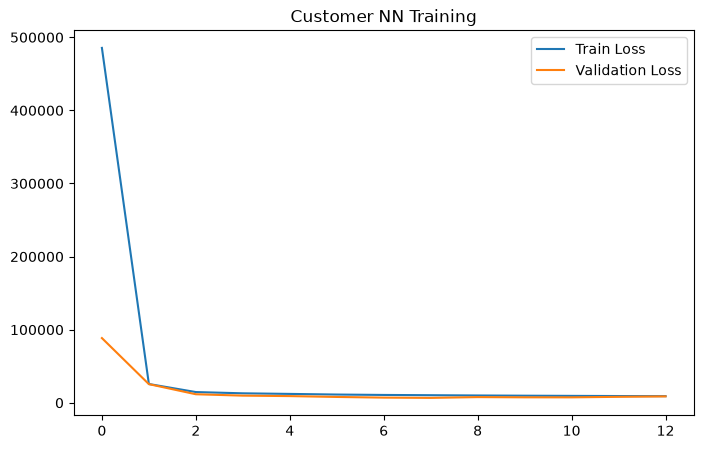

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    history.history["loss"],
    label="Train Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.legend()

plt.title(
    "Customer NN Training"
)

plt.show()

In [17]:
cust_nn_preds = customer_nn.predict(
    X_valid_scaled
).flatten()

1832/1832 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step


In [18]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

nn_mae = mean_absolute_error(
    y_valid_cust,
    cust_nn_preds
)

nn_rmse = np.sqrt(
    mean_squared_error(
        y_valid_cust,
        cust_nn_preds
    )
)

nn_r2 = r2_score(
    y_valid_cust,
    cust_nn_preds
)

print("Customer NN Results")
print("-"*30)
print(f"MAE  : {nn_mae:.2f}")
print(f"RMSE : {nn_rmse:.2f}")
print(f"R²   : {nn_r2:.4f}")

Customer NN Results
------------------------------
MAE  : 56.50
RMSE : 81.79
R²   : 0.9564


In [19]:
sales_drop_cols = [
    "Sales",
    "Date",
    "Open",
    "Customers"
]

X_train_sales = train.drop(
    columns=sales_drop_cols
)

X_valid_sales = valid.drop(
    columns=sales_drop_cols
)

y_train_sales = train["Sales"]
y_valid_sales = valid["Sales"]

print(X_train_sales.shape)
print(X_valid_sales.shape)

(733564, 47)
(58611, 47)


In [20]:
from sklearn.preprocessing import StandardScaler

sales_scaler = StandardScaler()

X_train_sales_scaled = sales_scaler.fit_transform(
    X_train_sales
)

X_valid_sales_scaled = sales_scaler.transform(
    X_valid_sales
)

In [27]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense,
    BatchNormalization,
    Dropout
)

sales_nn = Sequential([

    Dense(
        128,
        activation="relu",
        input_shape=(47,)
    ),
    BatchNormalization(),
    Dropout(0.2),

    Dense(
        64,
        activation="relu"
    ),
    BatchNormalization(),
    Dropout(0.2),

    Dense(
        32,
        activation="relu"
    ),
    BatchNormalization(),

    Dense(
        16,
        activation="relu"
    ),

    Dense(1)
])

c:\Users\Vedant\anaconda3\envs\demand-intel\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [23]:
import tensorflow as tf

In [28]:
sales_nn.compile(
    optimizer="adam",
    loss=tf.keras.losses.Huber(),
    metrics=["mae"]
)

In [29]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [30]:
history_sales = sales_nn.fit(
    X_train_sales_scaled,
    y_train_sales,

    validation_data=(
        X_valid_sales_scaled,
        y_valid_sales
    ),

    epochs=50,
    batch_size=512,

    callbacks=[early_stop],

    verbose=1
)

Epoch 1/50
1433/1433 ━━━━━━━━━━━━━━━━━━━━ 53s 27ms/step - loss: 5407.3066 - mae: 5407.8066 - val_loss: 1820.2734 - val_mae: 1820.7733
Epoch 2/50
1433/1433 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss: 1007.3062 - mae: 1007.8060 - val_loss: 664.5667 - val_mae: 665.0665
Epoch 3/50
1433/1433 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss: 788.1167 - mae: 788.6167 - val_loss: 661.1309 - val_mae: 661.6307
Epoch 4/50
1433/1433 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - loss: 745.8318 - mae: 746.3316 - val_loss: 651.3220 - val_mae: 651.8220
Epoch 5/50
1433/1433 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - loss: 718.4919 - mae: 718.9916 - val_loss: 658.7608 - val_mae: 659.2607
Epoch 6/50
1433/1433 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - loss: 698.8923 - mae: 699.3923 - val_loss: 691.3680 - val_mae: 691.8677
Epoch 7/50
1433/1433 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - loss: 682.5275 - mae: 683.0273 - val_loss: 662.0873 - val_mae: 662.5871
Epoch 8/50
1433/1433 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - loss: 670.7216 - mae: 671.2214 

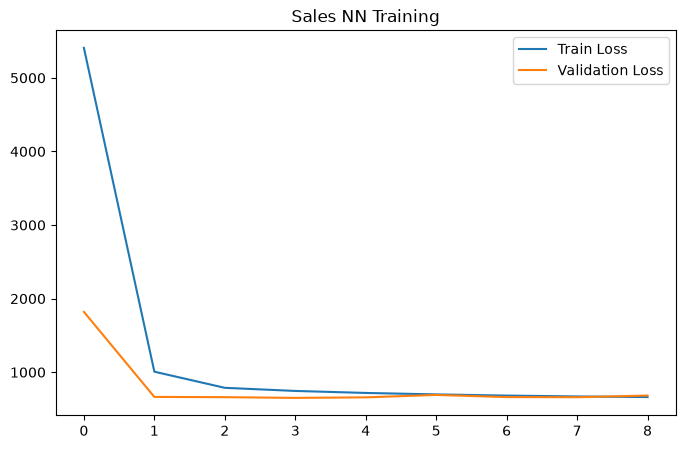

In [31]:


plt.figure(figsize=(8,5))

plt.plot(
    history_sales.history["loss"],
    label="Train Loss"
)

plt.plot(
    history_sales.history["val_loss"],
    label="Validation Loss"
)

plt.legend()

plt.title(
    "Sales NN Training"
)

plt.show()

In [32]:
sales_preds_nn = sales_nn.predict(
    X_valid_sales_scaled
).flatten()

sales_mae_nn = mean_absolute_error(
    y_valid_sales,
    sales_preds_nn
)

sales_rmse_nn = np.sqrt(
    mean_squared_error(
        y_valid_sales,
        sales_preds_nn
    )
)

sales_r2_nn = r2_score(
    y_valid_sales,
    sales_preds_nn
)

print("Sales NN Results")
print("-"*30)
print(f"MAE  : {sales_mae_nn:.2f}")
print(f"RMSE : {sales_rmse_nn:.2f}")
print(f"R²   : {sales_r2_nn:.4f}")

1832/1832 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
Sales NN Results
------------------------------
MAE  : 651.82
RMSE : 930.26
R²   : 0.9106


In [33]:
multi_drop_cols = [
    "Sales",
    "Customers",
    "Date",
    "Open"
]

In [34]:
X_train_multi = train.drop(
    columns=multi_drop_cols
)

X_valid_multi = valid.drop(
    columns=multi_drop_cols
)

print(X_train_multi.shape)
print(X_valid_multi.shape)

(733564, 47)
(58611, 47)


In [35]:
# Customer targets
y_train_customers = train["Customers"]
y_valid_customers = valid["Customers"]

# Sales targets
y_train_sales = train["Sales"]
y_valid_sales = valid["Sales"]

print(y_train_customers.shape)
print(y_valid_customers.shape)

print(y_train_sales.shape)
print(y_valid_sales.shape)

(733564,)
(58611,)
(733564,)
(58611,)


In [36]:
from sklearn.preprocessing import StandardScaler

multi_scaler = StandardScaler()

X_train_multi_scaled = multi_scaler.fit_transform(
    X_train_multi
)

X_valid_multi_scaled = multi_scaler.transform(
    X_valid_multi
)

In [37]:
from tensorflow.keras.layers import (
    Input,
    Dense,
    BatchNormalization,
    Dropout
)

from tensorflow.keras.models import Model

In [48]:
inputs = Input(shape=(47,))

x = Dense(256, activation="relu")(inputs)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)

x = Dense(128, activation="relu")(x)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)

x = Dense(64, activation="relu")(x)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)

shared = Dense(64, activation="relu")(x)

# Customer branch
cust = Dense(32, activation="relu")(shared)
cust = BatchNormalization()(cust)
cust = Dense(16, activation="relu")(cust)

customer_output = Dense(
    1,
    name="customer_output"
)(cust)

# Sales branch
sales = Dense(32, activation="relu")(shared)
sales = BatchNormalization()(sales)
sales = Dense(16, activation="relu")(sales)

sales_output = Dense(
    1,
    name="sales_output"
)(sales)

multi_task_model = Model(
    inputs=inputs,
    outputs=[
        customer_output,
        sales_output
    ]
)

In [49]:
from tensorflow.keras import optimizers

multi_task_model.compile(
    # Pass the optimizer object with your desired learning rate here
    optimizer=optimizers.Adam(learning_rate=0.0005),

    loss={
        "customer_output": "mse",
        "sales_output": "mse"
    },

    loss_weights={
    "customer_output": 1.6,
    "sales_output": 1.0
    },

    metrics={
        "customer_output": ["mae"],
        "sales_output": ["mae"]
    }
)

In [50]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

In [51]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6
)

In [52]:
history_multi = multi_task_model.fit(

    X_train_multi_scaled,

    {
        "customer_output": y_train_customers,
        "sales_output": y_train_sales
    },

    validation_data=(

        X_valid_multi_scaled,

        {
            "customer_output": y_valid_customers,
            "sales_output": y_valid_sales
        }
    ),

    epochs=100,
    batch_size=512,

    callbacks=[early_stop, reduce_lr],

    verbose=1
)

Epoch 1/100
1433/1433 ━━━━━━━━━━━━━━━━━━━━ 58s 29ms/step - customer_output_loss: 480168.0938 - customer_output_mae: 600.1404 - loss: 55523828.0000 - sales_output_loss: 54755208.0000 - sales_output_mae: 6773.9429 - val_customer_output_loss: 93172.7500 - val_customer_output_mae: 261.8703 - val_loss: 48154552.0000 - val_sales_output_loss: 48342180.0000 - val_sales_output_mae: 6417.2324 - learning_rate: 5.0000e-04
Epoch 2/100
1433/1433 ━━━━━━━━━━━━━━━━━━━━ 28s 19ms/step - customer_output_loss: 38185.3711 - customer_output_mae: 137.8220 - loss: 29884078.0000 - sales_output_loss: 29820152.0000 - sales_output_mae: 4984.7456 - val_customer_output_loss: 12385.6758 - val_customer_output_mae: 76.6062 - val_loss: 12311817.0000 - val_sales_output_loss: 12353205.0000 - val_sales_output_mae: 3273.3726 - learning_rate: 5.0000e-04
Epoch 3/100
1433/1433 ━━━━━━━━━━━━━━━━━━━━ 27s 19ms/step - customer_output_loss: 22040.6484 - customer_output_mae: 102.0692 - loss: 5504387.0000 - sales_output_loss: 5468417.

In [53]:
cust_preds_multi, sales_preds_multi = (
    multi_task_model.predict(
        X_valid_multi_scaled
    )
)

1832/1832 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step


In [54]:
cust_preds_multi = cust_preds_multi.flatten()
sales_preds_multi = sales_preds_multi.flatten()

In [55]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [56]:
cust_r2_multi = r2_score(
    y_valid_customers,
    cust_preds_multi
)

cust_rmse_multi = np.sqrt(
    mean_squared_error(
        y_valid_customers,
        cust_preds_multi
    )
)

print("cust_r2_multi:", cust_r2_multi)
print("cust_rmse_multi:", cust_rmse_multi)

cust_r2_multi: 0.9305835366249084
cust_rmse_multi: 103.21363615094664


In [57]:
sales_r2_multi = r2_score(
    y_valid_sales,
    sales_preds_multi
)

sales_rmse_multi = np.sqrt(
    mean_squared_error(
        y_valid_sales,
        sales_preds_multi
    )
)

print("sales_r2_multi:", sales_r2_multi)
print("sales_rmse_multi:", sales_rmse_multi)

sales_r2_multi: 0.9037467241287231
sales_rmse_multi: 965.2243262578912


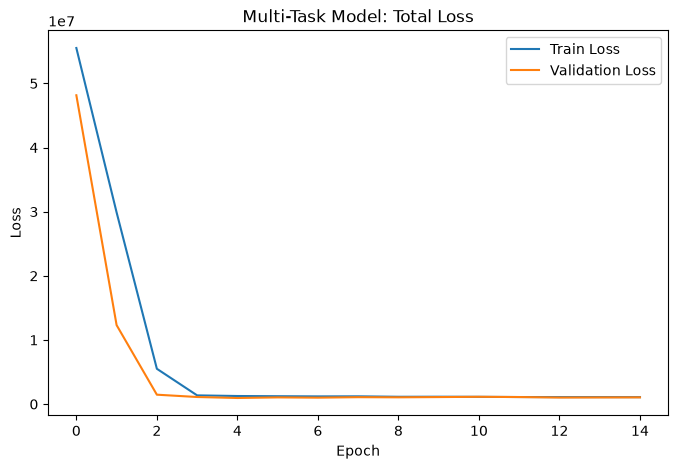

In [58]:
#Total loss
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history_multi.history['loss'], label='Train Loss')
plt.plot(history_multi.history['val_loss'], label='Validation Loss')

plt.title('Multi-Task Model: Total Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

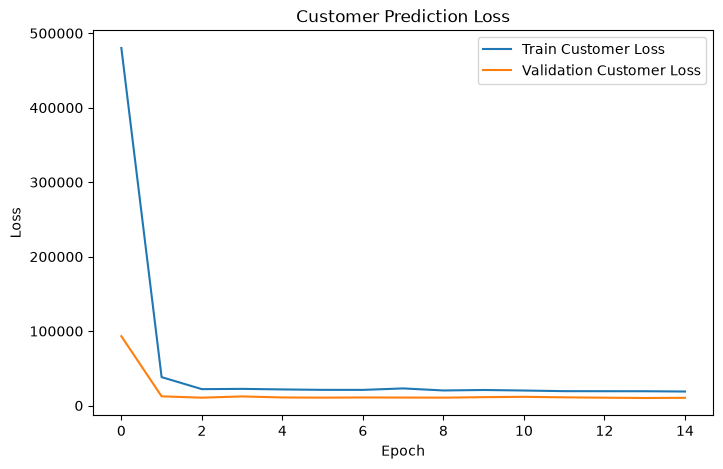

In [59]:
#Customer loss
plt.figure(figsize=(8,5))

plt.plot(
    history_multi.history['customer_output_loss'],
    label='Train Customer Loss'
)

plt.plot(
    history_multi.history['val_customer_output_loss'],
    label='Validation Customer Loss'
)

plt.title('Customer Prediction Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

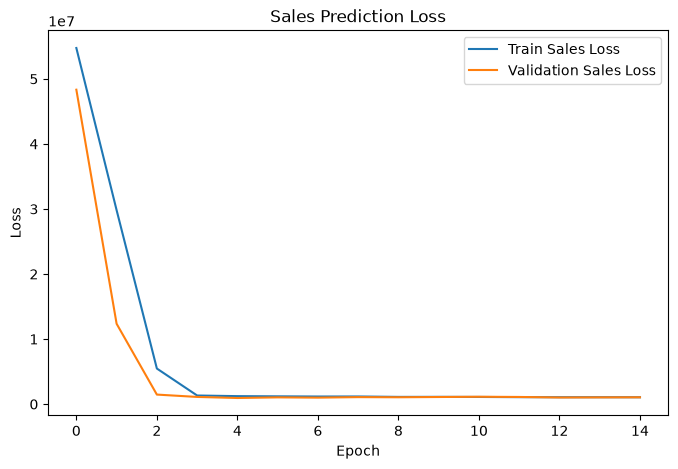

In [60]:
#Sales loss
plt.figure(figsize=(8,5))

plt.plot(
    history_multi.history['sales_output_loss'],
    label='Train Sales Loss'
)

plt.plot(
    history_multi.history['val_sales_output_loss'],
    label='Validation Sales Loss'
)

plt.title('Sales Prediction Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

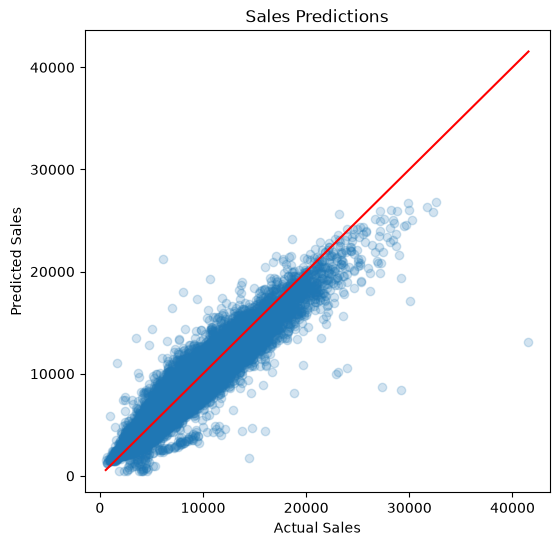

In [61]:
#Actual vs Predicted Sales Scatter Plot
plt.figure(figsize=(6,6))

plt.scatter(
    y_valid_sales,
    sales_preds_multi,
    alpha=0.2
)

plt.plot(
    [y_valid_sales.min(), y_valid_sales.max()],
    [y_valid_sales.min(), y_valid_sales.max()],
    'r'
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Sales Predictions")

plt.show()

In [6]:
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from xgboost import XGBRegressor

# -------------------------------------------------------
# Base Model
# -------------------------------------------------------

xgb = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1,
)

# -------------------------------------------------------
# Hyperparameter Search Space
# -------------------------------------------------------

param_grid = {
    "n_estimators": [250, 300, 350],
    "learning_rate": [0.03, 0.05, 0.07],
    "max_depth": [7, 8, 9],
    "min_child_weight": [1, 3],
    "subsample": [0.8, 0.9],
    "colsample_bytree": [0.8, 0.9],
    "gamma": [0, 0.1],
}


# -------------------------------------------------------
# Time Series Cross Validation
# -------------------------------------------------------

tscv = TimeSeriesSplit(n_splits=3)

# -------------------------------------------------------
# Random Search
# -------------------------------------------------------

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid,
    n_iter=20,
    scoring="r2",
    cv=tscv,
    verbose=2,
    random_state=42,
    n_jobs=-1,
)

# -------------------------------------------------------
# Train
# -------------------------------------------------------

random_search.fit(X_train_cust, y_train_cust)

# -------------------------------------------------------
# Best Model
# -------------------------------------------------------

best_xgb = random_search.best_estimator_

print("\nBest Parameters")
print(random_search.best_params_)

print("\nBest CV Score")
print(random_search.best_score_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits

Best Parameters
{'subsample': 0.8, 'n_estimators': 350, 'min_child_weight': 3, 'max_depth': 7, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 0.8}

Best CV Score
0.9524622956911722


In [8]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = best_xgb.predict(X_valid_cust)

mae = mean_absolute_error(y_valid_cust, y_pred)
rmse = np.sqrt(mean_squared_error(y_valid_cust, y_pred))
r2 = r2_score(y_valid_cust, y_pred)

print("Tuned XGBoost Results")
print("-" * 35)
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

Tuned XGBoost Results
-----------------------------------
MAE  : 52.57
RMSE : 75.38
R²   : 0.9630


In [1]:
import psutil

print("Physical Cores :", psutil.cpu_count(logical=False))
print("Logical Cores  :", psutil.cpu_count(logical=True))

Physical Cores : 4
Logical Cores  : 8


In [2]:
import psutil

ram = psutil.virtual_memory()

print(f"Total RAM : {ram.total / (1024**3):.2f} GB")
print(f"Available : {ram.available / (1024**3):.2f} GB")
print(f"Used      : {ram.used / (1024**3):.2f} GB")

Total RAM : 7.65 GB
Available : 1.09 GB
Used      : 6.56 GB
